### 构建一个bpe_tokenizer

#### 2.1：unicode standard

In [1]:
ord('牛')

29275

In [3]:
chr(29275)

'牛'

In [4]:
chr(0)

'\x00'

In [13]:
ord('中')

20013

In [11]:
chr(1)

'\x01'

#### 2.2 unicode-encoding

In [18]:
test = "hello world, 我喜欢你"
utf8_encoding = test.encode("utf-8")
utf8_encoding

b'hello world, \xe6\x88\x91\xe5\x96\x9c\xe6\xac\xa2\xe4\xbd\xa0'

In [20]:
print(list(utf8_encoding))

[104, 101, 108, 108, 111, 32, 119, 111, 114, 108, 100, 44, 32, 230, 136, 145, 229, 150, 156, 230, 172, 162, 228, 189, 160]


In [21]:
utf8_encoding.decode()

'hello world, 我喜欢你'

In [99]:
ord("1")

49

In [95]:
ord('牛')

29275

In [ ]:
print(chr(0))  # 返回空字符串

 


In [24]:
"this is a test" + chr(0) + "string"

'this is a test\x00string'

In [26]:
print("this is a test" + chr(0) + "string")

this is a test string


In [42]:
"hello".encode("utf-8")

b'hello'

In [ ]:
'hello'  # 是Unicode表示
b'hello'  # 是字节序列,是ASCII序列

b'hello'

In [ ]:
for b in b'hello': # [104, 101, 108, 108, 111]
    print(bytes(b))  # bytes(b)创建一个长度为b的bytes，且每个字节都是0
    print(bytes([b]))  # 将整数b转化为单字节bytes
    print(b)  # 整数b

b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
b'h'
104
b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
b'e'
101
b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00

In [45]:
def decode_utf8_btyes_to_str_wrong(bytestring: bytes):
    return "".join([bytes([b]).decode("utf-8") for b in bytestring])

In [46]:
decode_utf8_btyes_to_str_wrong("hello".encode("utf-8"))

'hello'

In [47]:
decode_utf8_btyes_to_str_wrong(b'hello')

'hello'

In [40]:
def decode_utf8_btyes_to_str_wrong(bytestring: bytes):
    return "".join([bytes(b).decode("utf-8") for b in bytestring])

In [ ]:
decode_utf8_btyes_to_str_wrong("hello".encode("utf-8"))  # 对于英文，其utf-8是单字节，因此可以成功
decode_utf8_btyes_to_str_wrong("你好".encode("utf-8"))  # 对于中文，其utf-8是多字节，因此对其解码会出错

'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x0

In [32]:
def add(a: int, b: int):
    return a + b

In [34]:
add(1, 2)

3

#### 2.3 subword tokenization  
bytes encoding可以解决word encoding的OOV（out-of-vocabulary）问题，但是也会带来一些问题:  
1. 序列过长，因为一个字符可能被多个字节所划分  
2. 语义破碎，模型需要从毫无相关的字节序列中重新学习语义  
因此就有了subword tokenization 

#### 2.4 BPE tokenizer traing

##### 2.4.1 Vocabulary initialization  
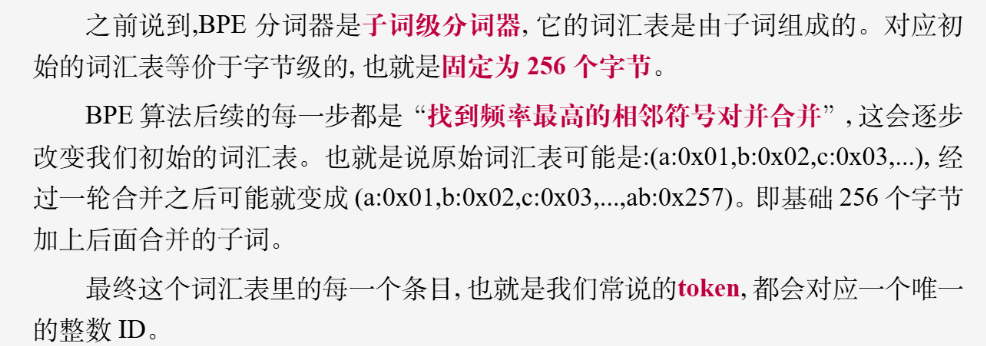

##### 2.4.2 pre-tokenization

In [ ]:
# '(?:[sdmt]|ll|ve|re) 匹配字符中的后缀，如's,'d, 'm, 't, 'll, 've, 're等等
# (?: ...) 是非捕捉组
# ?\p{L}+ 匹配：可选的前置空格+至少一个字母, + 表示一个或多个字母
# ?\p{N}+ 匹配： 可选的前置空格+至少一个数字, + 表示一个或多个数字
# ?[^\s\p{L}\p{N}]+  匹配：可选空格 + 非（空白\字母\数字）的字符序列 ^...表示匹配非...的内容
# \s+(?!\S)  匹配：尾部空白
# \s+ 所有剩下得空白字符
PAT =  r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+ | ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""

In [2]:
import regex as re

# re提供的模版函数：re.func(pattern, string, flags=0)


In [92]:
re.findall(PAT, "some text that i'll pre-tokeniza 123 !!!!!!")  # 返回所有匹配的字符串， 返回一个列表

['some ', 'text ', 'that ', "'ll", ' ', '-', 'tokeniza ', '123', ' !!!!!!']

In [65]:
re.finditer(PAT, "some text that i'll pre-tokeniza")

<regex.Match object; span=(0, 4), match='some'>

In [94]:
for i in range(ord("!"), ord("~") + 1):
    print(i)

33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126


In [3]:
def gpt2_bytes_to_unicode_local():
    """
    将字节转化为Unicode字符, 调用函数直接返回字典{字节:unicode字符}
    核心作用: 把所有 0~255 的字节映射到不会被 tokenizer 分词器“拆开”的 Unicode 字符，保证 BPE 分词对所有字节稳定可逆。
    因为所有的字符都要用0~255表示
    """
    bs = (
        list(range(ord("!"), ord("~") + 1))
        + list(range(ord("i"), ord("¬") + 1 ))
        + list(range(ord("®"), ord("ÿ") + 1))
    )  # 安全可见的unicode字符

    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    
    cs = [chr(n) for n in cs]
    return dict(zip(bs, cs))

bytes_to_unicode_map = gpt2_bytes_to_unicode_local()

In [4]:
print(bytes_to_unicode_map)

{33: '!', 34: '"', 35: '#', 36: '$', 37: '%', 38: '&', 39: "'", 40: '(', 41: ')', 42: '*', 43: '+', 44: ',', 45: '-', 46: '.', 47: '/', 48: '0', 49: '1', 50: '2', 51: '3', 52: '4', 53: '5', 54: '6', 55: '7', 56: '8', 57: '9', 58: ':', 59: ';', 60: '<', 61: '=', 62: '>', 63: '?', 64: '@', 65: 'A', 66: 'B', 67: 'C', 68: 'D', 69: 'E', 70: 'F', 71: 'G', 72: 'H', 73: 'I', 74: 'J', 75: 'K', 76: 'L', 77: 'M', 78: 'N', 79: 'O', 80: 'P', 81: 'Q', 82: 'R', 83: 'S', 84: 'T', 85: 'U', 86: 'V', 87: 'W', 88: 'X', 89: 'Y', 90: 'Z', 91: '[', 92: '\\', 93: ']', 94: '^', 95: '_', 96: '`', 97: 'a', 98: 'b', 99: 'c', 100: 'd', 101: 'e', 102: 'f', 103: 'g', 104: 'h', 105: 'i', 106: 'j', 107: 'k', 108: 'l', 109: 'm', 110: 'n', 111: 'o', 112: 'p', 113: 'q', 114: 'r', 115: 's', 116: 't', 117: 'u', 118: 'v', 119: 'w', 120: 'x', 121: 'y', 122: 'z', 123: '{', 124: '|', 125: '}', 126: '~', 127: '\x7f', 128: '\x80', 129: '\x81', 130: '\x82', 131: '\x83', 132: '\x84', 133: '\x85', 134: '\x86', 135: '\x87', 136: '\x

In [ ]:
def pre_tokenize_document(doc: str, bytes_to_unicode_map: Dict[int, str]) -> List[List[str]]:
    """预分词处理单个文件"""
    tokens = re.findall(GPT2_SPLIT_PATTERN, doc, flags=re.UNICODE)
    sequences = []
    for token in tokens:
        token_unicode = ''.join(bytes_to_unicode_map[b] for b in token.encode('utf-8'))
        sequences.append(list(token_unicode))
    return sequences

In [106]:
bytes_to_unicode_map[0]

'Ā'

In [108]:
ord('Ā')

256

In [109]:
chr(0)

'\x00'

In [112]:
unicode_to_bytes_map = {v : bytes([k]) for k, v in bytes_to_unicode_map.items()}

In [ ]:
unicode_to_bytes_map['!']

b'!'

In [119]:
vocab = {i : bytes([i]) for i in range(256)}
next_token_id = 256
existing_bytes = set(vocab.values())


In [122]:
vocab[1]

b'\x01'

In [125]:
str = "<|endofdtext|>"

In [ ]:
str.encode('utf-8')

NameError: name 'size' is not defined

In [131]:
import mmap
import random
def load_and_sample_data(
        file_path: str,
        sample_size: int = 2000,
        special_token: str = "<|endoftext|>",  # 用special_token 作为分隔符切隔文档
) -> str:
    """
    内存映射文件方式加载并采样文档, 把磁盘上的文件直接映射到内存地址空间，这样读取文件内容就像访问内存一样快，不需要传统的 read() 拷贝。
    mmap.mmap()创建一个内存映射对象，把文件的内容直接映射到内存，让你像操作数组一样访问文件，而不用 read() 去拷贝数据。
    f.fileno() 返回文件在操作系统中的文件描述符, mmap需要这个整数来知道要映射哪个文件
    0 表示映射整个文件, 如果只想映射前1MB, 可以写1024 * 1024
    access mmap的访问模式 mmap.ACCESS_READ 只读
    with ... as mm: python中的上下文管理器 在用完后会自动关闭 减少内存泄漏风险
    """
    try:
        with open(file_path, "r+", encoding='utf-8', errors='ignore') as f:
            with mmap.mmap(f.fileno(), 0, access=mmap.ACCESS_READ) as mm:
                documents = []
                start = 0
                while start < len(mm):
                    end = mm.find(special_token.encode('utf-8'), start)
                    if end == -1:
                        doc = mm[start:].decode('utf-8', errors='repalce').strip()
                        if doc:
                            documents.append(doc)
                        break

                    doc = mm[start:end].decode('utf-8', errors='replace').strip()
                    if doc:
                        documents.append(doc)
                    start = end + len(special_token)
                
                if len(documents) > sample_size:
                    documents = random.sample(documents, sample_size)
                
                return special_token.join(documents)
    except Exception as e:
        raise IOError(f"加载数据集失败： {e}")

In [136]:
input_path = "C:/Users/why/Desktop/cs336/assignment1/data/TinyStoriesV2-GPT4-valid.txt"
sample_size = 2
special_token = "<|endoftext|>"
text = load_and_sample_data(input_path, sample_size, special_token)

In [137]:
text

'Once upon a time, there was a little girl named Amy. She had a toy that she did not like. She would say, "I hate this toy!" Her mom heard her and felt sad.\nOne day, Amy\'s mom made her a tasty cake. She put a big zero on the cake. Amy asked, "Why is there a zero on my cake?" Her mom said, "Because it\'s a special cake for you."\nAmy ate the tasty cake and felt happy. She looked at the toy and thought, "Maybe I don\'t hate it. I will play with it now." And so, Amy played with the toy and had fun. She learned that it was okay to change her mind about things.<|endoftext|>Once upon a time, there was a cat named Tom. Tom loved to play with yarn. One day, Tom found a big ball of yarn. It was not a boring color. It was red and blue and made Tom very excite.\nTom played with the yarn all day. He rolled it, chased it, and jumped on it. The yarn made him very happy. Tom\'s friends, a dog and a bird, saw him play. They wanted to play with the yarn too.\nSo, they all played with the yarn togethe

In [140]:
import regex as re
escaped_token = re.escape(special_token)

document = [part for part in re.split(escaped_token, text) if part]

In [143]:
document[1]

"Once upon a time, there was a cat named Tom. Tom loved to play with yarn. One day, Tom found a big ball of yarn. It was not a boring color. It was red and blue and made Tom very excite.\nTom played with the yarn all day. He rolled it, chased it, and jumped on it. The yarn made him very happy. Tom's friends, a dog and a bird, saw him play. They wanted to play with the yarn too.\nSo, they all played with the yarn together. They had so much fun that they forgot how boring the day was before. They played until they were tired. Then, they all took a nap, dreaming of more exciting days with the yarn."

In [144]:
escaped_token

'<\\|endoftext\\|>'

In [17]:
# 预分词
import regex as re
from typing import Union, List, Tuple, Dict

# gpt2预分词的正则表达式
GPT2_SPLIT_PATTERN = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""

def pre_tokenize_document(doc: str, bytes_to_unicode_map: Dict[int, str]) -> List[List[str]]:
    """预分词处理单个文件"""
    tokens = re.findall(GPT2_SPLIT_PATTERN, doc, flags=re.UNICODE)
    print(tokens)
    sequences = []
    for token in tokens:
        token_unicode = ''.join(bytes_to_unicode_map[b] for b in token.encode('utf-8'))
        print(token_unicode)
        print(list(token_unicode))
        sequences.append(list(token_unicode))
    return sequences

In [18]:
seq = pre_tokenize_document("This is the text I'll pre-tokenized", bytes_to_unicode_map=bytes_to_unicode_map)

['This', ' is', ' the', ' text', ' I', "'ll", ' pre', '-', 'tokenized']
This
['T', 'h', 'i', 's']
Ġis
['Ġ', 'i', 's']
Ġthe
['Ġ', 't', 'h', 'e']
Ġtext
['Ġ', 't', 'e', 'x', 't']
ĠI
['Ġ', 'I']
'll
["'", 'l', 'l']
Ġpre
['Ġ', 'p', 'r', 'e']
-
['-']
tokenized
['t', 'o', 'k', 'e', 'n', 'i', 'z', 'e', 'd']


In [19]:
seq

[['T', 'h', 'i', 's'],
 ['Ġ', 'i', 's'],
 ['Ġ', 't', 'h', 'e'],
 ['Ġ', 't', 'e', 'x', 't'],
 ['Ġ', 'I'],
 ["'", 'l', 'l'],
 ['Ġ', 'p', 'r', 'e'],
 ['-'],
 ['t', 'o', 'k', 'e', 'n', 'i', 'z', 'e', 'd']]

In [20]:
from typing import Tuple

In [21]:
x: Tuple[int, int] = 1

In [22]:
x

1